# Parameterized Alpha Analysis of Multiple MGnify Studies

![MGnify](../assets/figs/mgnify_banner.png)

This notebook runs a complete bacterial diversity analysis using a configuration dictionary to control all parameters.

**Key features:**
1. Single configuration dictionary for all analysis parameters
4. Automated output management

**Pipeline with options**
1. Counts
2. Filter on minimum reads per sample
3. Filtering based on prok vs euk
4. Three cases of preprocessing for the final `alpha` diversity analysis

## Setup and Imports

In [1]:
from pathlib import Path

# Dataframes and display
import pandas as pd
import numpy as np
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Warning verbosity
import warnings 
warnings.filterwarnings(action="ignore")

from mgnify_methods.utils.logging import get_logger

logger = get_logger('nb_multiple_studies', level="INFO")
logger.info("Hello from mgnify_methods")
%matplotlib inline 

INFO | nb_multiple_studies | Hello from mgnify_methods


In [2]:
# Import all required functions
from momics.taxonomy import (
    fill_taxonomy_placeholders,
    rarefy_table,
    clean_tax_row,
)
# All low level functions are imported from the momics package
from momics.utils import load_and_clean

from mgnify_methods.taxonomy import (
    aggregate_by_taxonomic_level,
    pivot_taxonomic_data,
    remove_singletons_per_sample,
)
from mgnify_methods.stats import extract_sample_stats
from mgnify_methods.utils.plot import (
    plot_feature_reads_hist,
    plot_taxonomic_overlap,
    violin_plot_taxon,
)

from mgnify_methods.metacomp.rarefaction import (
    rarefaction_curve,
    calculate_min_rarefaction_depth,
)

from mgnify_methods.metacomp.diversity import alpha_diversity_analysis, run_permanova
from mgnify_methods.utils.io import (
    load_taxonomy_summary,
    filter_tax_summary,
    assert_taxonomy_integrity,
    filter_number_reads,
)

from mgnify_methods import TaxonomyTable, AbundanceTable
import mgnify_methods.paper_modules as pm

# Beta diversity
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

## Configuration Dictionary

All analysis parameters are defined here. Modify this dictionary to control the entire analysis flow.

In [ ]:
# ============================================================================
# ANALYSIS CONFIGURATION
# ============================================================================

CONFIG = {
    # === Data Sources ===
    'datasets': {
        'OSD2018': ['MGYS00006608', 'mgnify_data/ERP124424_taxonomy_abundances_SSU_v5.0.tsv'],
        'OSD2019': ['MGYS00006607', 'mgnify_data/ERP124431_taxonomy_abundances_SSU_v5.0.tsv'],
        'Sola': ['MGYS00006680', 'mgnify_data/SRP237882_taxonomy_abundances_SSU_v5.0.tsv'],
        # 'Tara': ['MGYS00000492', 'mgnify_data/ERP003634_taxonomy_abundances_SSU_v5.0.tsv'],
        'Biscay': ['MGYS00006682', 'mgnify_data/SRP334933_taxonomy_abundances_SSU_v5.0.tsv'],
        'Baltic': ['MGYS00006678', 'mgnify_data/ERP140185_taxonomy_abundances_SSU_v5.0.tsv'],
        'BBMO': ['MGYS00006675', 'mgnify_data/ERP122219_taxonomy_abundances_SSU_v5.0.tsv'],
        'Svalbard': ['MGYS00003725', 'mgnify_data/ERP106348_taxonomy_abundances_SSU_v5.0.tsv'],
        'Helgoland': ['MGYS00006686', 'mgnify_data/ERP144826_taxonomy_abundances_SSU_v5.0.tsv'],
        'Fram': ['MGYS00006714', 'mgnify_data/ERP151329_taxonomy_abundances_SSU_v5.0.tsv'],

    },
    
    # === Output Configuration ===
    'output': {
        'use_timestamp': True,  # Create timestamped output folder
        'cache_dir': 'analysis_cache',  # Cache directory for downloaded data
    },
    
    # === Filtering Parameters ===
    'filtering': {
        'min_reads_cutoff': 25000,  # Minimum reads per sample
        # 'prevalence_percent': 0.005,  # Prevalence cutoff (0.5%)
    },
    
    # === Taxonomic Settings ===
    'taxonomy': {
        'ranks': ['superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'],
        'analysis_level': 'phylum', #, 'class', 'order', 'family', 'genus',  # Levels for detailed analysis
        'filter_to_bacteria': True,  # Focus only on bacterial taxa
        "indicators": {
            "superkingdom": "sk__",
            "kingdom": "k__",
            "phylum": "p__",
            "class": "c__",
            "order": "o__",
            "family": "f__",
            "genus": "g__",
            "species": "s__",
            },
    },
    
    # === Sample Selection ===
    'samples': {
        'sample_type': 'prok',  # 'prok' or 'euk'
    },
    
    # === Preprocess Settings ===
    'preprocess': {
        'enabled': False,
        'method': 'rarefaction',
        'method_params': {
            'rarefaction': {
                'depth': None,  # None = auto-calculate minimum depth
                'n_points': 50,  # Number of points for rarefaction curves
            },
        },
    },

    # === Transform Settings for compositional data ===
    'transform': {
        'enabled': True,
        'method': 'clr',
        "params": {
            "pseudo_count": 1e-9
        },
        # Method-specific overrides
        "method_params": {
            "alr": {
                "reference_feature": "taxon_1"
            },
            "ilr": {
                "basis": "sbp"
            },
            "plr": {
                "lambda": 0.5
            }
        }
    },
    
    # === Diversity Analysis ===
    'diversity': {
        'alpha': {
            'enabled': True,
            'dropna': False,  # Drop NA values during aggregation
            'remove_singletons': False,  # Remove taxa appearing only once per sample
            'rarefy': False,  # Rarefy samples to minimum depth before alpha diversity analysis
        },
        'beta': {
            'enabled': True,
            'metric': 'euclidean', #'braycurtis',  # Beta diversity metric (e.g., 'braycurtis', 'jaccard')
            'remove_singletons': True,  # Remove taxa appearing only once per sample before beta diversity analysis
            'prevalence_cutoff': 0.5,  # Prevalence cutoff (0.5%)
        },
    },
    
    # === Feature Analysis ===
    'feature': 'study_tag',  # features to analyze
    
    # === Plot Flags ===
    'plots': {
        'reads_histogram': True,
        'taxonomic_overlap_venn': True,
        'rarefaction_curves': True,
        'rarefaction_mean_std': True,
        'rarefaction_mean_ci': True,
        'rarefaction_individual': False,  # Can be very cluttered
        'alpha_diversity': True,
        'beta_diversity_pcoa': True,
        'taxa_prevalence_violin': True,
        'feature_rarefaction': True,  # Rarefaction curves per feature value
        'save_figures': False,  # Save figures to output folder
        'dpi': 300,  # DPI for saved figures
    },
}

print("Configuration loaded successfully!")
print(f"\nDatasets: {list(CONFIG['datasets'].keys())}")
print(f"Taxonomic level for analysis: {CONFIG['taxonomy']['analysis_level']}")
print(f"Feature to analyze: {CONFIG['feature']}")

Configuration loaded successfully!

Datasets: ['OSD2018', 'OSD2019', 'Sola', 'Biscay', 'Baltic', 'BBMO', 'Svalbard', 'Helgoland', 'Fram']
Taxonomic level for analysis: phylum
Feature to analyze: study_tag


## Initialize Output Directories

In [4]:
# Extract configuration
TAXONOMY_RANKS = CONFIG['taxonomy']['ranks']
ds = CONFIG['datasets']

# Create output directories
if CONFIG['output']['use_timestamp']:
    stamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
    OUT_FOLDER = Path('analysis_' + stamp).resolve()
else:
    OUT_FOLDER = Path('analysis_latest').resolve()

ANALYSIS_CACHE = Path(CONFIG['output']['cache_dir']).resolve()

# add OUT_FOLDER to config for later use
CONFIG['output']['out_folder'] = str(OUT_FOLDER)
CONFIG['input'] = {'cache_dir': str(ANALYSIS_CACHE)}

for folder in [OUT_FOLDER, ANALYSIS_CACHE]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Directory ready: {folder}")

# Save configuration to output folder
import json
config_path = OUT_FOLDER / 'analysis_config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"\nConfiguration saved to: {config_path}")

Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260216_1317
Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_cache

Configuration saved to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260216_1317/analysis_config.json


## Load Metadata from MGnify

In [5]:
# Fetch analysis metadata
analysis_meta, samples_meta = pm.load_mgnify_meta(ANALYSIS_CACHE, ds)

INFO | mgnify_methods.utils.io | Analysis OSD2018 has 62 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2019 has 48 samples.
INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis Biscay has 52 samples.
INFO | mgnify_methods.utils.io | Analysis Baltic has 665 samples.
INFO | mgnify_methods.utils.io | Analysis BBMO has 249 samples.
INFO | mgnify_methods.utils.io | Analysis Svalbard has 159 samples.
INFO | mgnify_methods.utils.io | Analysis Helgoland has 357 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2019 has 48 samples.
INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis Biscay has 52 samples.
INFO | mgnify_methods.utils.io | Analysis Baltic has 665 samples.
INFO | mgnify_methods.utils.io | Analysis BBMO has 249 samples.
INFO | mgnify_methods.utils.io | Analysis Svalbard has 159 samples.
INFO | mgnify_methods.utils.io | Analysis Helgoland has 357 samples.
INFO | mgn

## Load EMO-BON data

In [6]:
root_folder = Path('../').resolve()
ssu, emobon_meta = pm.load_emobon(root_folder, ret='ssu')

In [7]:
ssu_filt = fill_taxonomy_placeholders(ssu, CONFIG['taxonomy']['ranks'])
ssu_filt = pivot_taxonomic_data(ssu_filt)


# unify taxonomic information to the MGnify
ssu_filt = ssu_filt.reset_index()
ssu_filt['taxonomic_concat'] = ssu_filt['taxonomic_concat'].apply(clean_tax_row)
ssu_filt = ssu_filt.reset_index()
# unify column and index names
ssu_filt.drop(columns=['ncbi_tax_id', 'index'], inplace=True)
ssu_filt = ssu_filt.rename(columns={
    'taxonomic_concat': '#SampleID',
})
ssu_filt.set_index('#SampleID', inplace=True)

## Merge metadata

In [8]:
samples_meta = pd.concat([emobon_meta, samples_meta], axis=0, sort=False)

## Filter Samples by Read Count


=== Reads Distribution (Unfiltered) ===


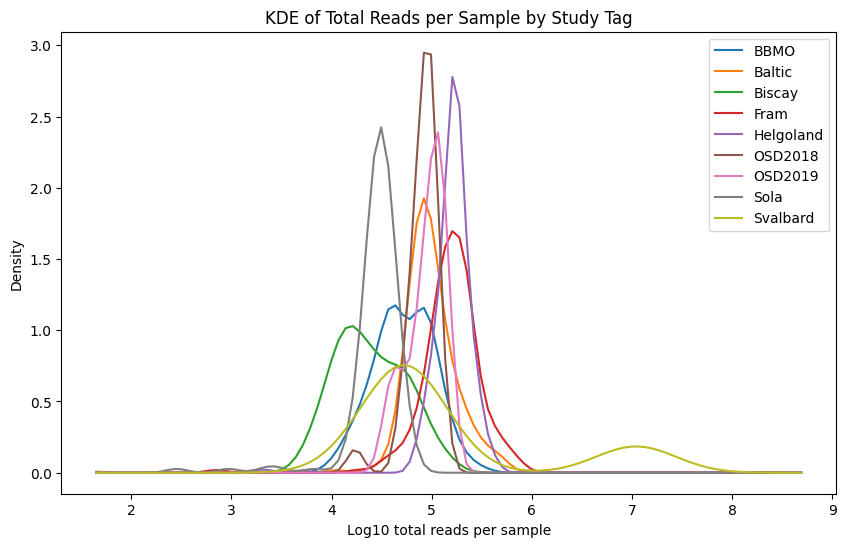

INFO | mgnify_methods.utils.io | Dropping 119 samples with less than 25000 reads: ['ERR4674146', 'ERR4674181', 'SRR10716900', 'SRR10716902', 'SRR10716915', 'SRR10716916', 'SRR10716928', 'SRR10716933', 'SRR10716938', 'SRR10716948', 'SRR10716962', 'SRR10716963', 'SRR10716966', 'SRR10716969', 'SRR10716974', 'SRR10716979', 'SRR10716983', 'SRR10716989', 'SRR10717005', 'SRR10716910', 'SRR10716970', 'SRR10716971', 'SRR10716985', 'SRR10716990', 'SRR10716950', 'SRR10716954', 'SRR10716972', 'SRR10716977', 'SRR10716988', 'SRR10716991', 'SRR10716995', 'SRR10716996', 'SRR10717002', 'SRR10717010', 'SRR10717023', 'SRR10717046', 'SRR10717050', 'SRR15678353', 'SRR15678354', 'SRR15678355', 'SRR15678361', 'SRR15678377', 'SRR15678381', 'SRR15678386', 'SRR15678389', 'SRR15678393', 'SRR15678359', 'SRR15678372', 'SRR15678376', 'SRR15678378', 'SRR15678380', 'SRR15678388', 'SRR15678391', 'SRR15678350', 'SRR15678351', 'SRR15678356', 'SRR15678373', 'SRR15678375', 'SRR15678379', 'SRR15678382', 'SRR15678387', 'SRR


Filtering samples with < 25000 reads: 119 samples to remove
Remaining analyses after filtering: 1921

=== Reads Distribution (Filtered) ===


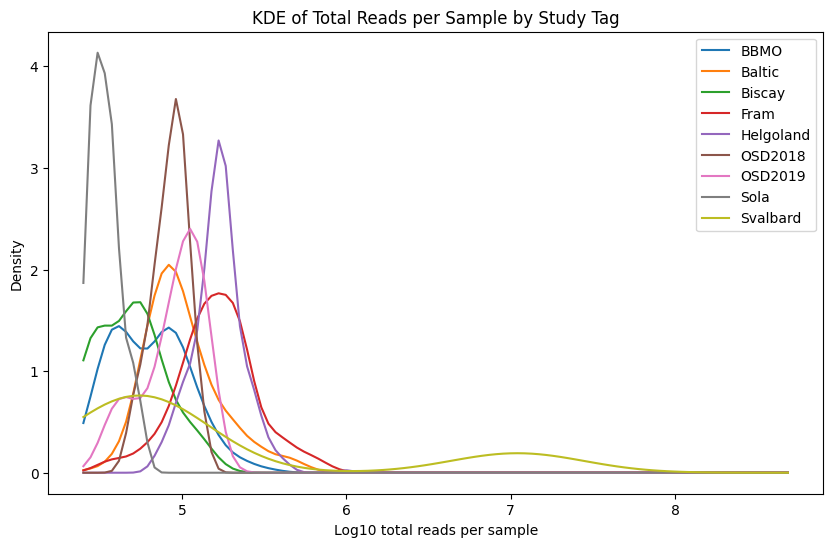

In [9]:
# Plot reads distribution before filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Unfiltered) ===")
    total_dict = plot_feature_reads_hist(
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
        bins=100,
    )

# Apply filtering
cutoff = CONFIG['filtering']['min_reads_cutoff']
to_drop = filter_number_reads(samples_meta, cutoff)
print(f"\nFiltering samples with < {cutoff} reads: {len(to_drop)} samples to remove")

for sample in to_drop:
    samples_meta = samples_meta[samples_meta.index != sample]

print(f"Remaining analyses after filtering: {len(samples_meta)}")

# Plot reads distribution after filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Filtered) ===")
    total_dict = plot_feature_reads_hist(
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_filtered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
        bins=100,
    )

## Load and Merge Taxonomy Data

In [10]:
# Get data folder path
root_folder = Path.cwd().parent
data_folder = root_folder / 'data'

df_tax_summary = load_taxonomy_summary(ds, data_folder)

INFO | mgnify_methods.utils.io | Loaded OSD2018: (1981, 62)


INFO | mgnify_methods.utils.io | Loaded OSD2019: (1708, 48)
INFO | mgnify_methods.utils.io | Loaded Sola: (3484, 283)
INFO | mgnify_methods.utils.io | Loaded Biscay: (118, 52)
INFO | mgnify_methods.utils.io | Loaded Baltic: (4316, 665)
INFO | mgnify_methods.utils.io | Loaded BBMO: (2503, 249)
INFO | mgnify_methods.utils.io | Loaded Svalbard: (1505, 81)
INFO | mgnify_methods.utils.io | Loaded Helgoland: (2241, 165)
INFO | mgnify_methods.utils.io | Loaded Fram: (1428, 205)
INFO | mgnify_methods.utils.io | 
Merged taxonomy table: (7265, 1810)


### Merge EMO-BON data

In [11]:
# merge ssu_filt and df_tax_summary on index
df_tax_summary = df_tax_summary.merge(
    ssu_filt,
    left_index=True,
    right_index=True,
    how='outer',
).fillna(0)
df_tax_summary.shape

(14393, 1991)

## Synchronize Metadata and Taxonomy Tables

In [12]:
# Remove samples not in metadata
df_tax_summary, samples_meta = filter_tax_summary(df_tax_summary, samples_meta)

# check data integrity
# assert_taxonomy_integrity(df_tax_summary, samples_meta)

INFO | mgnify_methods.utils.io | 
Before filtering: Taxonomy: 1991, metadata: 1921
INFO | mgnify_methods.utils.io | Taxonomy samples after filtering: 1731
INFO | mgnify_methods.utils.io | Metadata samples after filtering: 1731
INFO | mgnify_methods.utils.io | 
Removing 604 taxa with all zero counts


## Convert to TaxonomyTable Format

In [13]:
del ssu_filt
del analysis_meta
del emobon_meta

In [14]:
taxonomy_table = pm.clean_abundance_table(df_tax_summary, CONFIG)

INFO | mgnify_methods.tables.tables | Converting source: tax_mgnify_raw
WARNING | mgnify_methods.tables.tables | DataFrame is abundance without ncbi_tax_id data.
INFO | mgnify_methods.tables.tables | self.source before conversion to Taxonomy table: tax_mgnify_raw
INFO | mgnify_methods.tables.tables | Converting source: tax_processed
INFO | mgnify_methods.tables.sources.converters | Abundance dtype after conversion: uint32
INFO | mgnify_methods.tables.tables | Validating source: tax_processed
INFO | mgnify_methods.paper_modules | 
Taxonomy table ready: (563011, 9)


## Filter to Target Sample Type
- either `prok` or `euk`

In [15]:
# Get sample list for selected sample type
sample_type = CONFIG['samples']['sample_type']
sample_list = samples_meta.query("sample_type == @sample_type").index.tolist()

# Filter taxonomy table
taxonomy_table.df_filt = taxonomy_table.df[taxonomy_table.df.index.isin(sample_list)]

print(f"Filtered to {sample_type} samples: {len(sample_list)} samples")
print(f"Filtered taxonomy table: {taxonomy_table.df_filt.shape}")

Filtered to prok samples: 1731 samples
Filtered taxonomy table: (563011, 9)


## Taxonomic Overlap Analysis

In [16]:
# if CONFIG['plots']['taxonomic_overlap_venn']:
#     logger.info("\n=== Taxonomic Overlap Analysis ===")
#     plot_taxonomic_overlap(taxonomy_table, samples_meta, CONFIG)

## Preprocessing
- aggregate by taxonomic level (this is done on the Taxonomy table)
- then convert to abundance table
- then prevalence cutoff
- then preprocessing normlization `rarefaction`, `tss`, `tss_sqrt`

**This is supposed to be rewritten using only the OOP TaxonomyTable and AbendanceTable**

In [17]:
tax_level = CONFIG['taxonomy']['analysis_level']
table = aggregate_by_taxonomic_level(
    taxonomy_table.df_filt, level=tax_level, dropna=CONFIG['diversity']['alpha']['dropna']
)
del taxonomy_table

In [18]:
abundance_table = pivot_taxonomic_data(table)
type(abundance_table)

pandas.core.frame.DataFrame

## Beta diversity analysis

**Workflow**
1. Removing singletons
2. CLR transform


In [19]:
from mgnify_methods.taxonomy import (
    prevalence_cutoff_abund,
    remove_singletons_per_sample,
)
from mgnify_methods.metacomp.transforms import (
    apply_preprocessing_method,
    apply_transform_method,
)
from mgnify_methods.metacomp.diversity import beta_diversity_analysis
import numpy

### Preprocess

In [20]:
# remove singletons first before prevalence cutoff
if CONFIG['diversity']['beta']['remove_singletons']:
    abundance_table = remove_singletons_per_sample(abundance_table, skip_columns=0)
    logger.info("Removed singletons per sample")

abundance_table = prevalence_cutoff_abund(
    abundance_table, 
    percent=CONFIG['diversity']['beta']['prevalence_cutoff'],
    skip_columns=0
)

INFO | nb_multiple_studies | Removed singletons per sample


Removed 10 singleton features. Shape reduced from (264, 1731) → (254, 1731)
Prevalence cutoff at 0.5% (max threshold 3859.13): reduced from (254, 1731) to (115, 1731)


In [21]:
if CONFIG['preprocess']['enabled']:
    method = CONFIG['preprocess']['method']
    logger.info(f"\n=== Using method {method} ===")
    
    preprocess_tables = apply_preprocessing_method(abundance_table, method, CONFIG)
else:
    logger.info(f"No preprocessing")
    preprocess_tables = {CONFIG['samples']['sample_type']: abundance_table}

INFO | nb_multiple_studies | No preprocessing


### Data transform

In [22]:
if CONFIG['transform']['enabled']:
    transformed_tables = {}
    for sample_type, table_or_dict in preprocess_tables.items():
        if isinstance(table_or_dict, dict):
            transformed_tables[sample_type] = {
                tax_level: apply_transform_method(df, CONFIG)
                for tax_level, df in table_or_dict.items()
            }
        else:
            transformed_tables[sample_type] = apply_transform_method(table_or_dict, CONFIG)

    preprocess_tables = transformed_tables

INFO | mgnify_methods.metacomp.transforms | 
=== Applying transform clr ===


### Beta diversity

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
# dist = pdist(clr_data, metric="euclidean")

INFO | mgnify_methods.metacomp.diversity | 
=== Beta Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 1731 samples, 115 taxa
INFO | mgnify_methods.metacomp.diversity | Metric: euclidean
INFO | mgnify_methods.metacomp.diversity | Explained variance: PC1=49.43%, PC2=6.75%


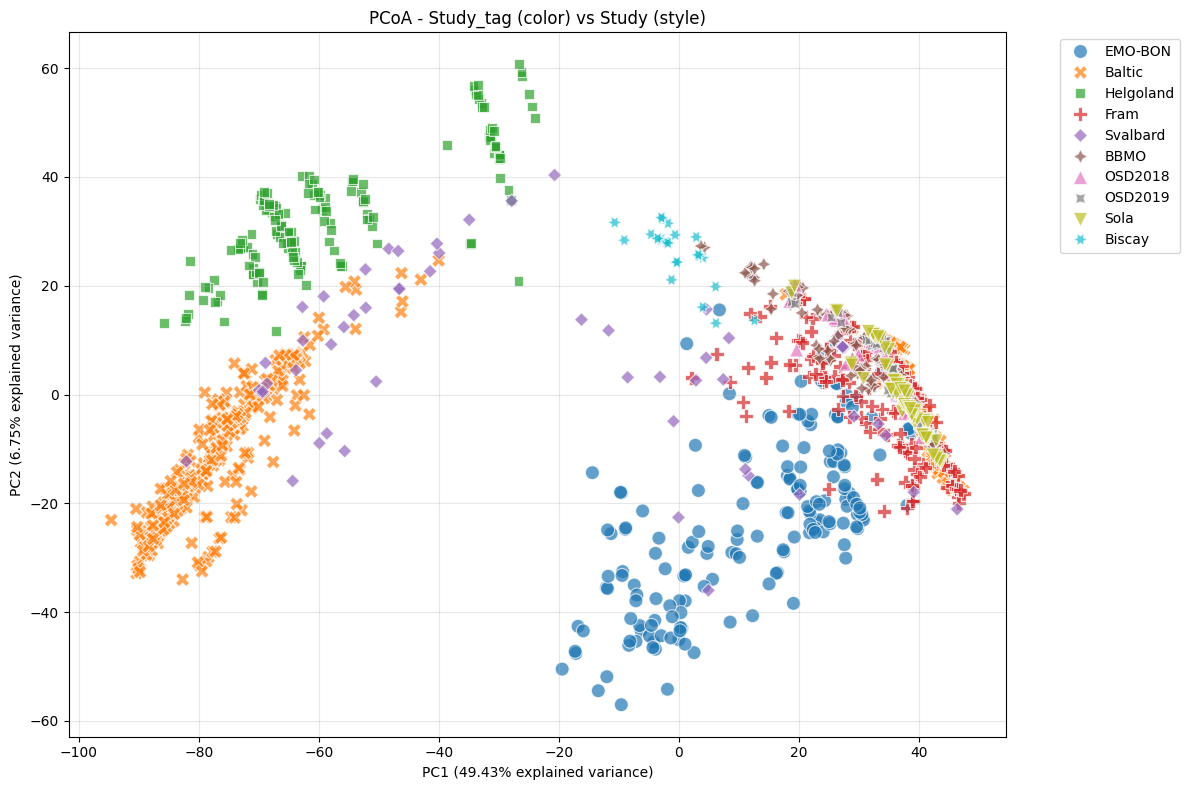

In [24]:
sample_type = CONFIG['samples']['sample_type']
CONFIG['diversity']['beta']['metric'] = 'euclidean'
beta_diversity_analysis(preprocess_tables[sample_type], samples_meta, config=CONFIG)

In [25]:
# [k for k in preprocess_tables[sample_type].index.to_list() if 'Chloroflexi' in k]

### Permanova

In [ ]:
from mgnify_methods.metacomp.diversity import run_permanova_factors, permanova_stat_dfs
import pickle

In [27]:
factor_list = ['season', 'year', 'study_tag']

results = run_permanova_factors(
    preprocess_tables[sample_type],
    samples_meta,
    factor_list,
    metric='euclidean',
)

df_p, df_p_granular, df_f, df_f_granular = permanova_stat_dfs(results, factor_list)

 33%|███▎      | 1/3 [00:18<00:37, 18.96s/it]WARNING | mgnify_methods.metacomp.diversity | Error running PERMANOVA for year=2020: All values in the grouping vector are the same. This method cannot operate on a grouping vector with only a single group of objects (e.g., there are no 'between' distances because there is only a single group).
WARNING | mgnify_methods.metacomp.diversity | Error running PERMANOVA for year=2003: All values in the grouping vector are the same. This method cannot operate on a grouping vector with only a single group of objects (e.g., there are no 'between' distances because there is only a single group).
WARNING | mgnify_methods.metacomp.diversity | Error running PERMANOVA for year=2004: All values in the grouping vector are the same. This method cannot operate on a grouping vector with only a single group of objects (e.g., there are no 'between' distances because there is only a single group).
WARNING | mgnify_methods.metacomp.diversity | Error running PERMANO

In [35]:
save_path = OUT_FOLDER / 'permanova_dict.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(results, f)

df_p.to_csv(OUT_FOLDER / 'permanova_p.csv')

df_f.to_csv(OUT_FOLDER / 'permanova_f.csv')

df_p_granular.to_csv(OUT_FOLDER / 'permanova_p_granular.csv')

df_f_granular.to_csv(OUT_FOLDER / 'permanova_f_granular.csv')

In [36]:
results['season_all']['study_tag'], results['study_tag_all']['season']

(method name               PERMANOVA
 test statistic name        pseudo-F
 sample size                    1731
 number of groups                 10
 test statistic            78.907977
 p-value                      0.0005
 number of permutations         1999
 Name: PERMANOVA results, dtype: object,
 method name               PERMANOVA
 test statistic name        pseudo-F
 sample size                    1731
 number of groups                  4
 test statistic            12.786816
 p-value                      0.0005
 number of permutations         1999
 Name: PERMANOVA results, dtype: object)

In [29]:
df_p, df_f

(           season    year study_tag
 season        NaN  0.0005    0.0005
 year       0.0005     NaN    0.0005
 study_tag  0.0005  0.0005       NaN,
               season       year  study_tag
 season           NaN  17.654956  78.907977
 year       12.786816        NaN  78.907977
 study_tag  12.786816  17.654956        NaN)

In [30]:
df_p_granular, df_f_granular

(                   season    year study_tag
 season_Summer         NaN  0.0005    0.0005
 season_Spring         NaN  0.0005    0.0005
 season_Autumn         NaN  0.0005    0.0005
 season_Winter         NaN  0.0005    0.0005
 year_2018          0.0005     NaN    0.0005
 year_2019          0.0005     NaN    0.0005
 year_2016          0.0005     NaN    0.0005
 year_2015          0.0005     NaN     0.001
 year_2017          0.4605     NaN    0.0085
 study_tag_Sola     0.0005   0.003       NaN
 study_tag_Baltic   0.0025  0.0375       NaN
 study_tag_BBMO     0.0005   0.013       NaN
 study_tag_Fram     0.2895  0.0005       NaN
 study_tag_EMO-BON  0.0005   0.002       NaN,
                       season      year  study_tag
 season_Summer            NaN  7.878101  52.323598
 season_Spring            NaN  4.930758  19.975005
 season_Autumn            NaN   5.35613   20.94259
 season_Winter            NaN  4.601615  22.292727
 year_2018          24.435778       NaN  46.248909
 year_2019        

### OLD

In [31]:
# results = {}
# metric = 'braycurtis'
# samples_meta_no_na = samples_meta.dropna(axis=1)

# # Within summer samples, does it matter which study site they came from? → tests study_tag
# # "Within summer samples, does it matter which year they were sampled? → tests year
# for season in samples_meta_no_na['season'].unique():
#     result = run_permanova(
#         preprocess_tables[sample_type],
#         samples_meta_no_na,
#         permanova_factor='season',
#         permanova_group=[season],
#         permanova_additional_factors=['study_tag', 'year'],
#         metric=metric,
#     )
#     results[season] = result

# for study in samples_meta_no_na['study_tag'].unique():
#     try:
#         result = run_permanova(
#             preprocess_tables[sample_type],
#             samples_meta_no_na,
#             permanova_factor='study_tag',
#             permanova_group=[study],
#             permanova_additional_factors=['season', 'year'],
#             metric=metric,
#         )
#         results[study] = result
#     except:
#         pass

# for year in samples_meta_no_na['year'].unique():
#     try:
#         result = run_permanova(
#             preprocess_tables[sample_type],
#             samples_meta_no_na,
#             permanova_factor='year',
#             permanova_group=[year],
#             permanova_additional_factors=['study_tag', 'season'],
#             metric=metric,
#         )
#         results[year] = result
#     except:
#         pass


In [32]:
# # create a dataframe with the results
# df = pd.DataFrame()
# for key in results.keys():
#     for subkey in results[key].keys():
#         df.loc[key, subkey] = results[key][subkey]['test statistic']